# 1. Library Import 

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, json

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                              confusion_matrix, roc_auc_score, f1_score,
                              roc_curve, auc)
from imblearn.over_sampling import SMOTE

# 2. Load dataset

In [99]:
file_path = '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'
train_df = pd.read_csv(file_path)

print("Dataset Telco Churn Berhasil Dimuat!")
print(f"Dimensi Data: {train_df.shape[0]} Baris, {train_df.shape[1]} Kolom")
print(f"\nDistribusi Target:\n{train_df['Churn'].value_counts()}")
print(f"Persentase Churn: {train_df['Churn'].value_counts(normalize=True)*100}")

Dataset Telco Churn Berhasil Dimuat!
Dimensi Data: 7043 Baris, 21 Kolom

Distribusi Target:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Persentase Churn: Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


# 3. Feature dan Label

In [100]:
train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'].replace(' ', np.nan), errors='coerce')

# Encode target ke 0/1 (INI PENTING - sering bikin akurasi jelek kalau skip)
train_df['Churn'] = train_df['Churn'].map({'Yes': 1, 'No': 0})

X = train_df.drop(columns=['customerID', 'Churn'])
y = train_df['Churn']

print(f"✅ Pemisahan Fitur dan Target Selesai.")
print(f"Jumlah Fitur: {X.shape[1]} kolom | Target: {y.name}")
print(f"Missing Values:\n{X.isnull().sum()[X.isnull().sum() > 0]}")

✅ Pemisahan Fitur dan Target Selesai.
Jumlah Fitur: 19 kolom | Target: Churn
Missing Values:
TotalCharges    11
dtype: int64


# 4. Split Dataset

In [101]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Split Data Selesai:")
print(f"   - Jumlah Data Training : {X_train_raw.shape[0]} baris")
print(f"   - Jumlah Data Testing  : {X_test_raw.shape[0]} baris")

✅ Split Data Selesai:
   - Jumlah Data Training : 5634 baris
   - Jumlah Data Testing  : 1409 baris


# 5. Preprocessing


In [102]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())  # WAJIB untuk KNN!
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed  = preprocessor.transform(X_test_raw)

print(f"✅ Preprocessing Selesai!")
print(f"Dimensi data training setelah encode: {X_train_processed.shape}")

✅ Preprocessing Selesai!
Dimensi data training setelah encode: (5634, 46)


# 6. Handling Imbalance (SMOTE)

In [107]:
from imblearn.over_sampling import SMOTE

# Versi A: Data Asli (Imbalance)
X_train_asli = X_train_processed
y_train_asli = y_train

# Versi B: SMOTE (Balanced)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print(f" Dua Versi Data Siap Diuji:")
print(f"   - Data Asli (Imbalance) : {X_train_asli.shape[0]} baris")
print(f"   - Data SMOTE (Balanced) : {X_train_smote.shape[0]} baris")
print(f"\nDistribusi SMOTE:\n{pd.Series(y_train_smote).value_counts()}")

 Dua Versi Data Siap Diuji:
   - Data Asli (Imbalance) : 5634 baris
   - Data SMOTE (Balanced) : 8278 baris

Distribusi SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


# 7. Training dan Hyperparameter (HPO)

In [108]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier

# Parameter grid yang lebih lengkap
param_grid = {
    'n_neighbors': list(range(1, 31, 2)),  # K ganjil: 1,3,5,...,29
    'weights': ['uniform', 'distance'],     # tambah 'distance'!
    'metric': ['euclidean', 'manhattan']    # coba 2 metric jarak
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- Menjalankan HPO pada Data Asli (Imbalance) ---")
grid_asli = GridSearchCV(
    KNeighborsClassifier(), param_grid, 
    cv=cv, scoring='roc_auc',  # pakai roc_auc bukan accuracy!
    n_jobs=-1, verbose=1
)
grid_asli.fit(X_train_asli, y_train_asli)
best_params_asli = grid_asli.best_params_

print("\n--- Menjalankan HPO pada Data SMOTE (Balanced) ---")
grid_smote = GridSearchCV(
    KNeighborsClassifier(), param_grid,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
grid_smote.fit(X_train_smote, y_train_smote)
best_params_smote = grid_smote.best_params_

print(f"\n[HPO Selesai]")
print(f"Best Params Asli  : {best_params_asli}")
print(f"Best Params SMOTE : {best_params_smote}")

--- Menjalankan HPO pada Data Asli (Imbalance) ---
Fitting 5 folds for each of 60 candidates, totalling 300 fits

--- Menjalankan HPO pada Data SMOTE (Balanced) ---
Fitting 5 folds for each of 60 candidates, totalling 300 fits

[HPO Selesai]
Best Params Asli  : {'metric': 'euclidean', 'n_neighbors': 29, 'weights': 'uniform'}
Best Params SMOTE : {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}


# 8. Akurasi dan Threshold

In [109]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

# Buat model final dari best params
knn_asli_final = KNeighborsClassifier(**best_params_asli).fit(X_train_asli, y_train_asli)
knn_smote_final = KNeighborsClassifier(**best_params_smote).fit(X_train_smote, y_train_smote)

# Prediksi
y_pred_asli  = knn_asli_final.predict(X_test_processed)
y_pred_smote = knn_smote_final.predict(X_test_processed)

y_proba_asli  = knn_asli_final.predict_proba(X_test_processed)[:, 1]
y_proba_smote = knn_smote_final.predict_proba(X_test_processed)[:, 1]

# Metrics lengkap
acc_asli  = accuracy_score(y_test, y_pred_asli)
acc_smote = accuracy_score(y_test, y_pred_smote)
roc_asli  = roc_auc_score(y_test, y_proba_asli)
roc_smote = roc_auc_score(y_test, y_proba_smote)
f1_asli   = f1_score(y_test, y_pred_asli)
f1_smote  = f1_score(y_test, y_pred_smote)

print(f"Akurasi Model Data Asli  : {acc_asli*100:.2f}%")
print(f"Akurasi Model Data SMOTE : {acc_smote*100:.2f}%")
print(f"ROC-AUC Data Asli        : {roc_asli:.4f}")
print(f"ROC-AUC Data SMOTE       : {roc_smote:.4f}")
print(f"F1-Score Data Asli       : {f1_asli:.4f}")
print(f"F1-Score Data SMOTE      : {f1_smote:.4f}")

Akurasi Model Data Asli  : 78.50%
Akurasi Model Data SMOTE : 72.04%
ROC-AUC Data Asli        : 0.8302
ROC-AUC Data SMOTE       : 0.7788
F1-Score Data Asli       : 0.5866
F1-Score Data SMOTE      : 0.5533


# 9. Confusion Matrix

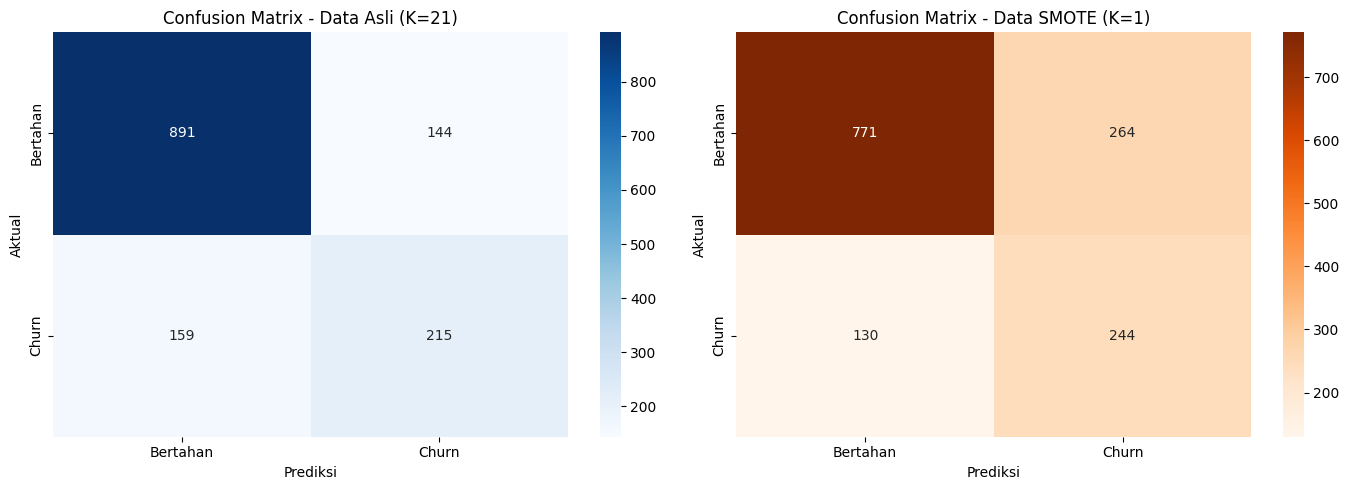

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Heatmap Data Asli
cm_asli = confusion_matrix(y_test, y_pred_asli)
sns.heatmap(cm_asli, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Bertahan', 'Churn'], yticklabels=['Bertahan', 'Churn'])
ax[0].set_title(f'Confusion Matrix - Data Asli (K={best_k_asli})')
ax[0].set_xlabel('Prediksi')
ax[0].set_ylabel('Aktual')

# Plot Heatmap Data SMOTE
cm_smote = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Oranges', ax=ax[1],
            xticklabels=['Bertahan', 'Churn'], yticklabels=['Bertahan', 'Churn'])
ax[1].set_title(f'Confusion Matrix - Data SMOTE (K={best_k_smote})')
ax[1].set_xlabel('Prediksi')
ax[1].set_ylabel('Aktual')

plt.tight_layout()
plt.show()

# 10. Detail Perbandingan

In [112]:
print("KESIMPULAN EVALUASI (DATA ASLI VS SMOTE)")
print(f"{'Metrik':<20} {'Data Asli':>12} {'Data SMOTE':>12}")
print("-" * 46)
print(f"{'Akurasi':<20} {acc_asli*100:>11.2f}% {acc_smote*100:>11.2f}%")
print(f"{'ROC-AUC':<20} {roc_asli:>12.4f} {roc_smote:>12.4f}")
print(f"{'F1-Score':<20} {f1_asli:>12.4f} {f1_smote:>12.4f}")

if roc_asli >= roc_smote:
    print(f"\nROC-AUC DATA ASLI ({roc_asli:.4f}) lebih unggul.")
    model_final = knn_asli_final
else:
    print(f"\nROC-AUC DATA SMOTE ({roc_smote:.4f}) lebih unggul.")
    model_final = knn_smote_final

KESIMPULAN EVALUASI (DATA ASLI VS SMOTE)
Metrik                  Data Asli   Data SMOTE
----------------------------------------------
Akurasi                    78.50%       72.04%
ROC-AUC                    0.8302       0.7788
F1-Score                   0.5866       0.5533

ROC-AUC DATA ASLI (0.8302) lebih unggul.


# 11. Simpan Model


In [113]:
import os
import joblib
import json

# Menyesuaikan target folder model di struktur VS Code kamu (naik 1 folder ke folder utama)
target_dir = '../models'
os.makedirs(target_dir, exist_ok=True)

# Menyimpan model terbaik (knn_asli_final) hasil pilihan dari langkah nomor 10
joblib.dump(knn_asli_final, os.path.join(target_dir, 'knn_model.pkl'))
joblib.dump(preprocessor, os.path.join(target_dir, 'knn_preprocessor.pkl'))
joblib.dump(nama_fitur_final, os.path.join(target_dir, 'knn_selected_features.pkl'))

# Menyimpan konfigurasi parameter ke JSON
with open(os.path.join(target_dir, 'best_params_knn_telco.json'), 'w') as f:
    json.dump({
        'n_neighbors': int(knn_asli_final.n_neighbors), 
        'weights': str(knn_asli_final.weights)
    }, f, indent=2)

print("✅ Seluruh file model .pkl sukses diexport ke folder 'models/'!")
print("Isi folder models saat ini:", os.listdir(target_dir))
print("-" * 60)

✅ Seluruh file model .pkl sukses diexport ke folder 'models/'!
Isi folder models saat ini: ['best_params_knn.json', 'best_params_knn_telco.json', 'best_params_rf.json', 'knn_metadata.pkl', 'knn_model.pkl', 'knn_preprocessor.pkl', 'knn_selected_features.pkl', 'model_metadata.pkl', 'preprocessor_knn.pkl', 'random_forest_model.pkl', 'rf_label_encoders.pkl', 'rf_scaler.pkl', 'selected_features.pkl']
------------------------------------------------------------


# 12. Sanity Check


In [114]:
# Menguji 5 sampel data pertama dari pengujian menggunakan model terbaik
sampel_uji = X_test_processed[:5]
hasil_prediksi = knn_asli_final.predict(sampel_uji)
probabilitas = knn_asli_final.predict_proba(sampel_uji)[:, 1]

tabel_pengecekan = pd.DataFrame({
    'Data Aktual'       : y_test.iloc[:5].values,
    'Prediksi Model k-NN': hasil_prediksi,
    'Probabilitas Churn': probabilitas.round(3)
})

print("\n=== HASIL SANITY CHECK FINAL MODEL ===")
print(tabel_pengecekan)


=== HASIL SANITY CHECK FINAL MODEL ===
   Data Aktual  Prediksi Model k-NN  Probabilitas Churn
0            0                    0               0.000
1            0                    1               0.862
2            0                    0               0.034
3            0                    0               0.345
4            0                    0               0.034
